In [19]:
# Cell 1 -- imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

In [20]:
# Cell 2 -- load data
df = pd.read_csv("data/engineered_2021_2023.csv")

print(df.shape)
print(df["season"].value_counts().sort_index())
print(df["next_score"].value_counts())

(106386, 17)
season
2021    35608
2022    35304
2023    35474
Name: count, dtype: int64
next_score
off_td        53418
off_fg        41023
no_score       9057
def_td         2173
def_safety      497
off_safety      218
Name: count, dtype: int64


In [21]:
# Cell 3 -- train/val split on season
# Temporal split, not random. Plays within a game are correlated with each
# other -- same teams, same weather, same game script. Random k-fold would
# let the model see 2023 game context during training, which inflates val
# performance. Holding out the full 2023 season gives a clean test of
# whether the model generalizes forward in time.
train = df[df["season"].isin([2021, 2022])].copy()
val   = df[df["season"] == 2023].copy()

print(f"Train: {len(train):,} rows | Val: {len(val):,} rows")

Train: 70,912 rows | Val: 35,474 rows


In [22]:
# Cell 4 -- define features and target
# These 9 columns are the model inputs. season and game_id stay in the
# dataframe for bookkeeping but are never passed to the model. The raw
# columns (down, ydstogo, etc.) are also excluded -- the model sees only
# the encoded and scaled versions.
# yardline_100_sq_scaled and is_red_zone_scaled are new in this version.
# They were added after Phase 3v1 showed yardline_100 had near-zero feature
# importance because a linear term could not capture red zone nonlinearity.
FEATURES = [
    "down_2", "down_3", "down_4",        # one-hot encoded down; down_1 is the reference category
    "ydstogo_log_scaled",                 # log-compressed and scaled yards to go
    "yardline_100_scaled",                # scaled distance from opponent end zone
    "yardline_100_sq_scaled",             # squared term to capture red zone nonlinearity
    "score_differential_scaled",          # scaled score context
    "half_seconds_remaining_scaled",      # scaled time left in the half
    "is_red_zone_scaled",                 # explicit flag for inside opponent 20
]

X_train = train[FEATURES].values
X_val   = val[FEATURES].values

y_train_raw = train["next_score"].values
y_val_raw   = val["next_score"].values

In [23]:
# Cell 5 -- refit scaler on train only
# The scaler in Phase 2 was fit on the full dataset, which was fine for EDA.
# Here it matters: if we fit on val data too, the scaler learns val set
# statistics and the validation results look artificially clean. Fit on
# train only, then apply the same transform to val.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

In [24]:
# Cell 6 -- encode target labels
# XGBoost requires integer class labels in the range 0..N-1. LabelEncoder
# gives us a consistent string-to-integer mapping. We save the encoder in
# Phase 3 so Phase 5 can convert integer predictions back to named outcomes
# without guessing what index maps to what class.
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_val   = le.transform(y_val_raw)

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

Class mapping:
  0: def_safety
  1: def_td
  2: no_score
  3: off_fg
  4: off_safety
  5: off_td


In [25]:
# Cell 7 -- logistic regression baseline
# Logistic regression gives us an interpretable baseline to compare XGBoost
# against. If XGBoost doesn't meaningfully beat it, that's a signal the
# features aren't carrying enough nonlinear signal to justify the added
# complexity. solver=lbfgs handles multinomial natively. max_iter=1000
# because the default 100 often fails to converge with this many classes.
lr = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)

lr_probs = lr.predict_proba(X_val)
lr_logloss = log_loss(y_val, lr_probs)
print(f"Logistic Regression log-loss: {lr_logloss:.4f}")

Logistic Regression log-loss: 0.9912


In [26]:
# Cell 8 -- XGBoost
# XGBoost should outperform logistic regression here because the relationship
# between field position and scoring probability is nonlinear (red zone spike,
# FG range sweet spot) and interactions between features matter (4th and short
# near midfield is very different from 4th and short at the opponent's 35).
# multi:softprob returns class probabilities directly, which is what we need
# for log-loss evaluation and EP calculation in Phase 5.
# early_stopping_rounds halts training when val loss stops improving, so we
# save the best checkpoint rather than the last one.
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    early_stopping_rounds=25,
    random_state=42,
    n_jobs=-1
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_probs = xgb.predict_proba(X_val)
xgb_logloss = log_loss(y_val, xgb_probs)
print(f"\nXGBoost best round: {xgb.best_iteration}")
print(f"XGBoost log-loss: {xgb_logloss:.4f}")

[0]	validation_0-mlogloss:1.06317
[50]	validation_0-mlogloss:0.97891
[100]	validation_0-mlogloss:0.97010
[142]	validation_0-mlogloss:0.97059

XGBoost best round: 117
XGBoost log-loss: 0.9698


In [27]:
# Cell 9 -- Brier scores by class
# Brier score is the mean squared error of probability estimates for a single
# class treated as binary. It complements log-loss because it is easier to
# interpret: 0 is perfect, 1 is maximally wrong. It also penalizes confident
# wrong predictions less severely than log-loss does, so the two metrics
# together give a fuller picture of calibration quality.
# off_safety and def_safety will have higher Brier scores than their sample
# share would suggest -- 218 and 497 observations is not enough for the model
# to learn reliable probability estimates for rare events.
print(f"{'Class':<15} {'LR':>8} {'XGB':>8}")
print("-" * 33)

for i, cls in enumerate(le.classes_):
    binary_true = (y_val == i).astype(int)
    lr_brier  = brier_score_loss(binary_true, lr_probs[:, i])
    xgb_brier = brier_score_loss(binary_true, xgb_probs[:, i])
    print(f"{cls:<15} {lr_brier:>8.4f} {xgb_brier:>8.4f}")

Class                 LR      XGB
---------------------------------
def_safety        0.0066   0.0066
def_td            0.0223   0.0224
no_score          0.0702   0.0646
off_fg            0.2364   0.2286
off_safety        0.0020   0.0020
off_td            0.2411   0.2390


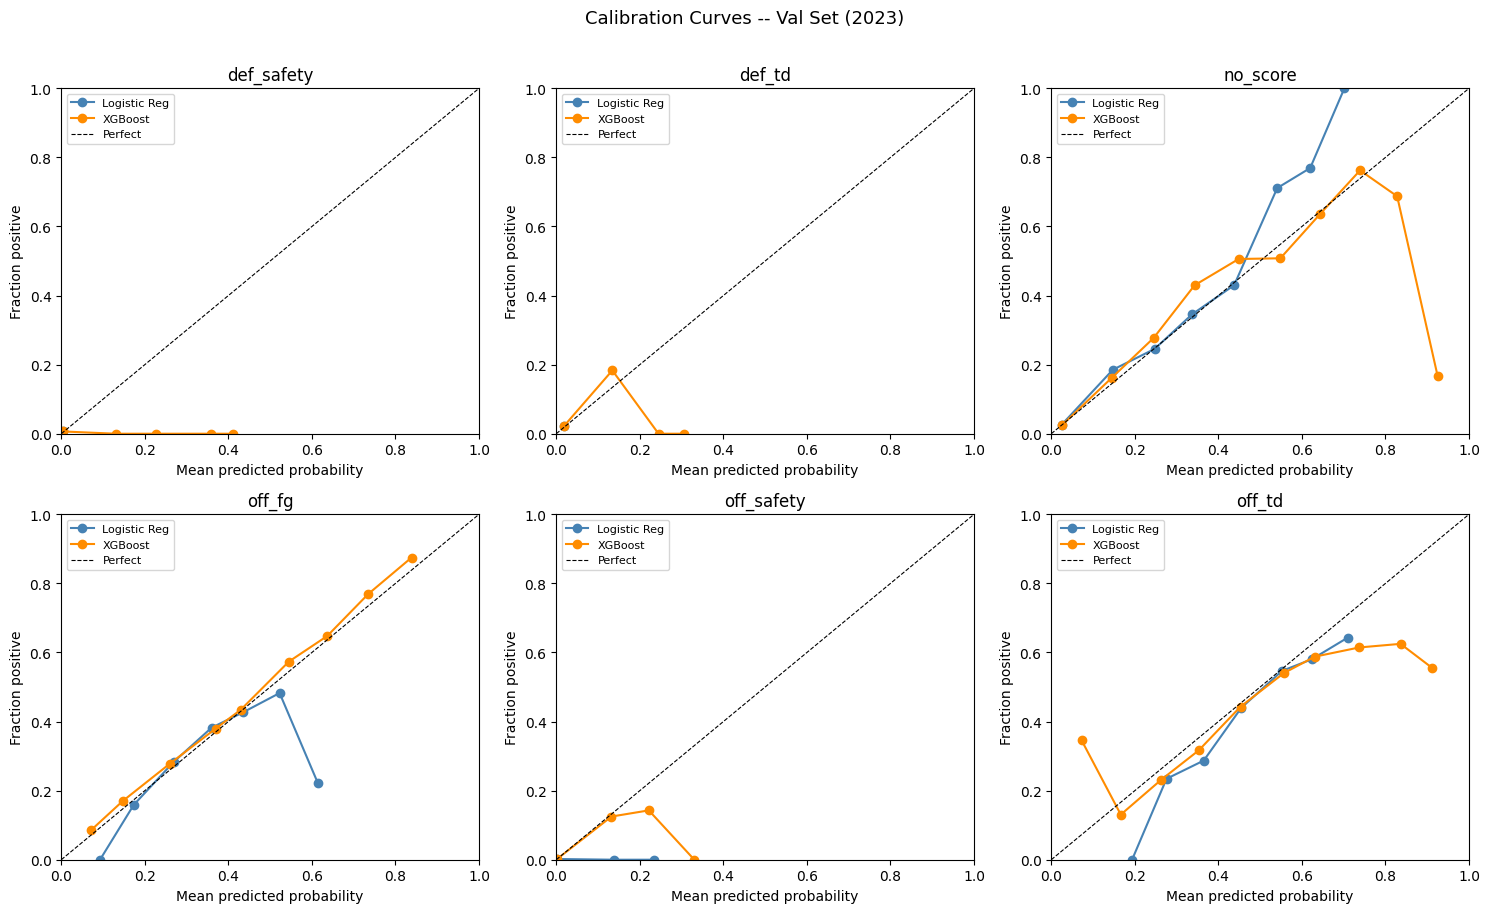

In [28]:
# Cell 10 -- calibration curves
# A perfectly calibrated model's curve tracks the diagonal: when it says 30%
# probability, the outcome happens 30% of the time. Deviations above the
# diagonal mean the model is underconfident; deviations below mean it is
# overconfident. We plot both models on the same axes for each class so the
# comparison is direct. off_safety and def_safety curves will be jagged
# because of low sample counts -- that is expected, not a bug.
os.makedirs("figures", exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, cls in enumerate(le.classes_):
    ax = axes[i]
    binary_true = (y_val == i).astype(int)

    for probs, label, color in [
        (lr_probs,  "Logistic Reg", "steelblue"),
        (xgb_probs, "XGBoost",      "darkorange")
    ]:
        fraction_pos, mean_pred = calibration_curve(
            binary_true, probs[:, i], n_bins=10, strategy="uniform"
        )
        ax.plot(mean_pred, fraction_pos, marker="o", label=label, color=color)

    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect")
    ax.set_title(cls)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction positive")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle("Calibration Curves -- Val Set (2023)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# Cell 11 -- feature importance
# Check that yardline_100 and down are now among the top features.
# In the first version of this model, qtr_scaled dominated at 44x the gain
# of yardline_100_scaled, which suppressed field position signal entirely.
# Removing qtr and adding yardline_100_sq and is_red_zone should fix that.
importance = xgb.get_booster().get_score(importance_type="gain")
importance_df = pd.DataFrame(
    importance.items(), columns=["feature", "gain"]
)
importance_df["feature_name"] = [FEATURES[int(f[1:])] for f in importance_df["feature"]]
importance_df = importance_df.sort_values("gain", ascending=False)

print("Feature importance by gain:")
print(importance_df[["feature_name", "gain"]].to_string(index=False))

Feature importance by gain:
                 feature_name     gain
half_seconds_remaining_scaled 9.347021
    score_differential_scaled 6.322625
                       down_4 4.722849
                       down_3 4.249937
           is_red_zone_scaled 3.662814
       yardline_100_sq_scaled 3.342230
          yardline_100_scaled 3.150702
           ydstogo_log_scaled 2.388099
                       down_2 1.665989


In [30]:
# Cell 12 -- save artifacts
# Everything Phase 5 needs to make predictions is saved here: the scaler to
# transform new inputs, the label encoder to convert integer predictions back
# to named outcomes, and both models so we can compare EP values side by side
# if needed. Saving all four now means Phase 5 has no dependency on this
# notebook being open or re-run.
os.makedirs("models", exist_ok=True)

joblib.dump(lr,     "models/logistic_regression.pkl")
joblib.dump(xgb,    "models/xgboost.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(le,     "models/label_encoder.pkl")

print("Saved:")
print("  models/logistic_regression.pkl")
print("  models/xgboost.pkl")
print("  models/scaler.pkl")
print("  models/label_encoder.pkl")

Saved:
  models/logistic_regression.pkl
  models/xgboost.pkl
  models/scaler.pkl
  models/label_encoder.pkl


In [31]:
# Cell 13 -- final summary
# One clean comparison to close out the notebook. These are the numbers to
# reference in PROCESS.md and when explaining the model to someone unfamiliar
# with log-loss: XGBoost improved on logistic regression but the margin is
# modest, which means the features are doing most of the work.
print("Model Comparison -- 2023 Validation Set")
print(f"{'Metric':<20} {'Logistic Reg':>15} {'XGBoost':>15}")
print("-" * 52)
print(f"{'Log-Loss':<20} {lr_logloss:>15.4f} {xgb_logloss:>15.4f}")
print(f"\nXGBoost best round: {xgb.best_iteration} of 300")

Model Comparison -- 2023 Validation Set
Metric                  Logistic Reg         XGBoost
----------------------------------------------------
Log-Loss                      0.9912          0.9698

XGBoost best round: 117 of 300
